In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.linear_model import LogisticRegression

X_train = pd.read_csv('../data/X_train.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()

model = LogisticRegression(class_weight= 'balanced', max_iter=5000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,5000
,multi_class,'deprecated'


In [3]:
df = pd.read_csv('../data/churn_cleaned.csv')

df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

mybins = [-1, 0, 12, 24, 36, df['tenure'].max()]
mylabels = ['New', '0-1 year', '1-2 years', '2-3 years', '3+ years']
df['tenure_groups'] = pd.cut(x= df['tenure'], bins= mybins, labels= mylabels)

df_ready = pd.get_dummies(data= df, drop_first= True, dtype= int)

feature_names = df_ready.drop('Churn', axis=1).columns

In [4]:
#Extract the coefficients
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

In [5]:
#create a absolute value coefficient column and sort in descending order
feature_importance['abs_coef'] = feature_importance['Coefficient'].abs()
feature_importance = feature_importance.sort_values(by='abs_coef', ascending=False)

feature_importance.head(10)

,Feature,Coefficient,abs_coef
1,tenure,-1.193949,1.193949
2,MonthlyCharges,-0.966386,0.966386
10,InternetService_Fiber optic,0.814786,0.814786
25,Contract_Two year,-0.629679,0.629679
33,tenure_groups_3+ years,0.593417,0.593417
30,tenure_groups_0-1 year,0.345113,0.345113
24,Contract_One year,-0.301510,0.301510
23,StreamingMovies_Yes,0.291835,0.291835
21,StreamingTV_Yes,0.278656,0.278656
3,TotalCharges,0.255019,0.255019


Text(0, 0.5, 'Feature')

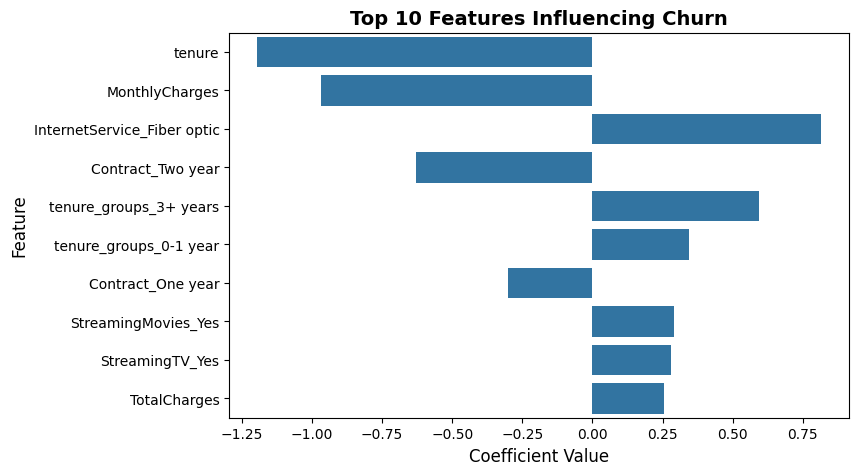

In [6]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8, 5))
sns.barplot(data=top_features, x='Coefficient', y='Feature')
plt.title("Top 10 Features Influencing Churn", fontweight='bold', fontsize=14)
plt.xlabel("Coefficient Value", fontsize=12)
plt.ylabel("Feature", fontsize=12)

Key Drivers of Churn

Customer loyalty, measured by tenure, emerges as the primary churn predictor, with longer-term customers showing the lowest churn risk. Contrary to expectations, higher monthly charges correlate with reduced churn, indicating premium customer loyalty. Service quality (fiber optic) and contractual commitment (two-year contracts) further enhance retention, while accumulated total charges increase churn susceptibility.